# v8: Using RafDB + AffectNet Dataset

Changes made compared to v7:

1. Exploration of possible tuning to improve results
  - Balanced sampling (higher leverage)
  - Slightly soften crops (Subtle mouth/eye cues help Sad/Disgust.) from scale=(0.7, 1.0) to scale=(0.8, 1.0)



# 1. RAF-DB + AffectNet Dataset Balancing
Dataset preparation, targeted balancing, and visualization of balancing.

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
kagglehub path: /kaggle/input/raf-db-dataset


100%|██████████| 8.12G/8.12G [06:07<00:00, 23.7MB/s]

Extracting files...


kagglehub path: /root/.cache/kagglehub/datasets/manavukani/affectnet/versions/1
RAF root: /content/data/raf-db
AffectNet root: /content/data/affectnet
[RAF-DB] root=/content/data/raf-db
  total images: 15339
  label-from-path matches (sampled): 10000
[AffectNet] root=/content/data/affectnet
  total images: 31002
  label-from-path matches (sampled): 10000
RAF-DB images parsed: 15339
AffectNet images parsed: 27823
RAF-DB counts: {'surprise': 1619, 'fear': 355, 'disgust': 877, 'happiness': 5957, 'sadness': 2460, 'anger': 867, 'neutral': 3204}
AffectNet counts: {'surprise': 4296, 'fear': 3622, 'disgust': 2660, 'happiness': 5045, 'sadness': 3430, 'anger': 3638, 'neutral': 5132}
Merged counts: {'surprise': 5915, 'fear': 3977, 'disgust': 3537, 'happiness': 11002, 'sadness': 5890, 'anger': 4505, 'neutral': 8336}


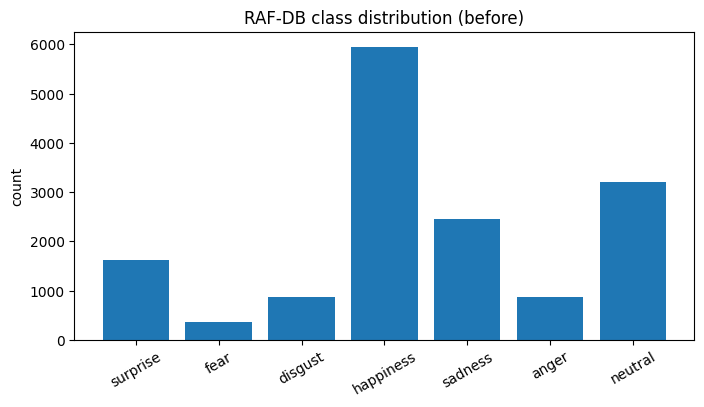

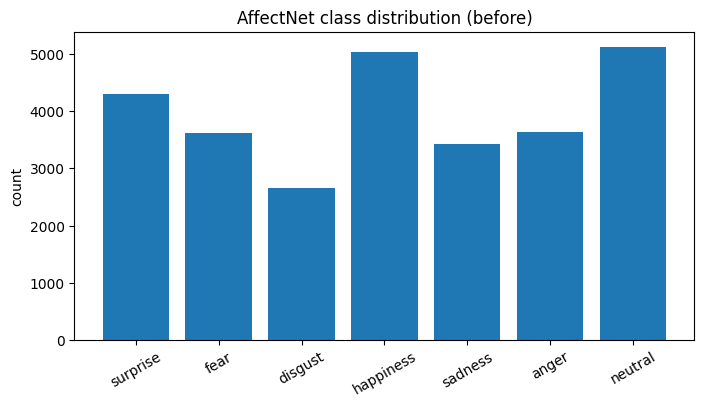

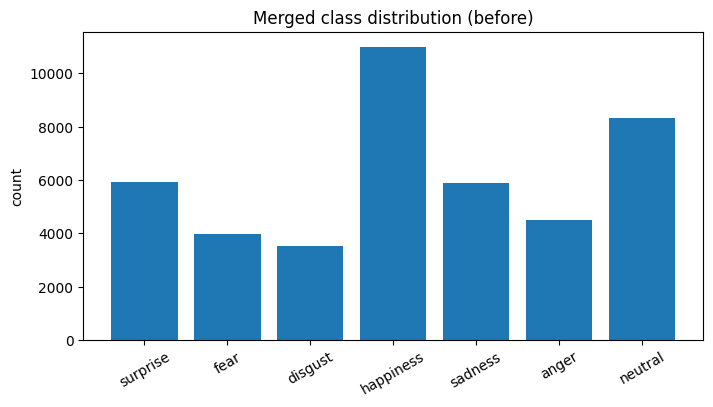

Target classes: ['surprise', 'fear', 'disgust', 'happiness', 'sadness', 'anger', 'neutral']
Calibration classes: []
Added from AffectNet: 4282
After dedup total: 19585
After full rebalance (downsample+topup): {'surprise': 2000, 'fear': 1982, 'disgust': 1991, 'happiness': 2000, 'sadness': 2000, 'anger': 1993, 'neutral': 2000}
Counts after: {'surprise': 2000, 'fear': 1982, 'disgust': 1991, 'happiness': 2000, 'sadness': 2000, 'anger': 1993, 'neutral': 2000}


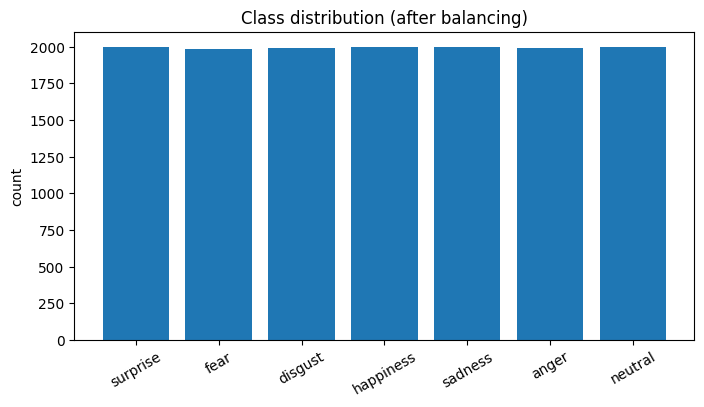

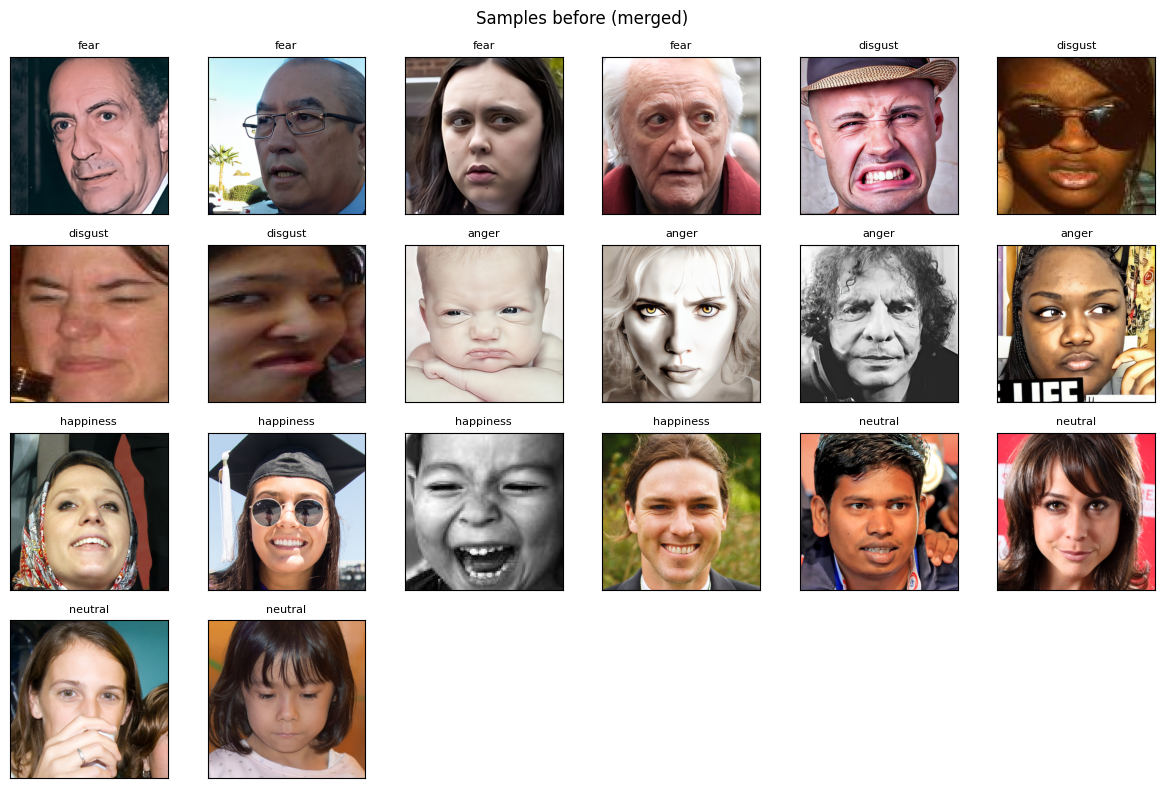

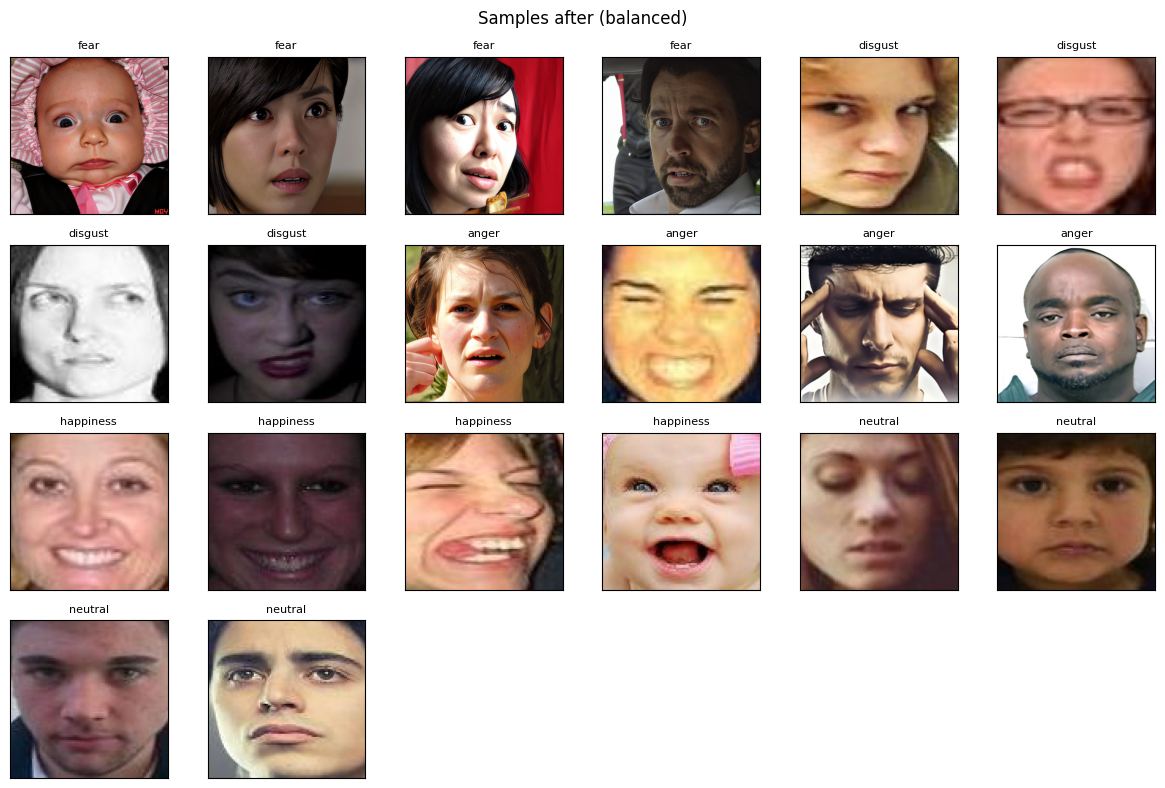

Before: {'surprise': 5915, 'fear': 3977, 'disgust': 3537, 'happiness': 11002, 'sadness': 5890, 'anger': 4505, 'neutral': 8336}
After : {'surprise': 2000, 'fear': 1982, 'disgust': 1991, 'happiness': 2000, 'sadness': 2000, 'anger': 1993, 'neutral': 2000}
fear      : +-1995 (from 3977 to 1982)
disgust   : +-1546 (from 3537 to 1991)
anger     : +-2512 (from 4505 to 1993)
happiness : +-9002 (from 11002 to 2000)
neutral   : +-6336 (from 8336 to 2000)


In [ ]:

# =======================
# 0) Config
# =======================

DATA_ROOT = "/content/data"
TARGET_CLASSES = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
TARGET_PER_CLASS = 2000  # or min(existing_counts.values())
CALIBRATION_CLASSES = []
CALIBRATION_RATIO = 0


# kagglehub dataset IDs
RAF_SLUG = "shuvoalok/raf-db-dataset"
AFFECT_SLUG = "manavukani/affectnet"

# ========================================
# 1) Download datasets with kagglehub
# ========================================

# install kagglehub just for download convenience
try:
    import kagglehub  # noqa
except Exception:
    %pip -q install kagglehub

import os, glob, shutil, pathlib
from pathlib import Path
import kagglehub

def kh_download(slug, dest_root):
    if not slug:
        print("Slug empty, skipping.")
        return None
    print(f"Downloading via kagglehub: {slug}")
    p = kagglehub.dataset_download(slug)
    print("kagglehub path:", p)
    # Copy or link into DATA_ROOT
    dest = Path(dest_root)
    dest.mkdir(parents=True, exist_ok=True)
    # If path contains zips, expand them into dest
    # First, mirror folder into dest to simplify later paths
    if Path(p).resolve() != dest.resolve():
        # try to move contents, keep idempotent
        for item in Path(p).iterdir():
            tgt = dest / item.name
            if item.is_dir():
                if not tgt.exists():
                    shutil.copytree(item, tgt)
            else:
                if not tgt.exists():
                    shutil.copy2(item, tgt)
    # Unzip any archives found
    zips = list(dest.rglob("*.zip"))
    for z in zips:
        os.system(f'unzip -q -o "{z}" -d "{z.parent}"')
    return str(dest)

raf_root = kh_download(RAF_SLUG, os.path.join(DATA_ROOT, "raf-db"))
aff_root = kh_download(AFFECT_SLUG, os.path.join(DATA_ROOT, "affectnet"))
print("RAF root:", raf_root)
print("AffectNet root:", aff_root)

# ========================================
# 2) Imports and helpers
# ========================================

import os, sys, glob, random, json, math, time, hashlib
from collections import Counter, defaultdict
import pandas as pd
import torch
import torchvision
from torchvision.io import read_image
import matplotlib.pyplot as plt

random.seed(17)
torch.manual_seed(17)
os.makedirs(DATA_ROOT, exist_ok=True)

STD_LABELS = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
IMG_EXTS = {'.jpg','.jpeg','.png'}

# ========================================
# 3) Label normalization + folder-label inference
# ========================================

# Mapping for RAF-DB numeric scheme
LABEL_MAP_NUMERIC_RAF = {
    1: 'surprise',
    2: 'fear',
    3: 'disgust',
    4: 'happiness',
    5: 'sadness',
    6: 'anger',
    7: 'neutral'
}

# Mapping for AffectNet folder names to match RAF numeric
AFFECTNET_TO_NUMERIC = {
    'surprise': 1,
    'fear': 2,
    'disgust': 3,
    'happy': 4,       # affectnet folder uses "happy"
    'happiness': 4,
    'sad': 5,
    'sadness': 5,
    'anger': 6,
    'neutral': 7,
    # contempt dropped
}


def normalize_label(name_or_idx, dataset='raf'):
    """
    Converts folder or numeric labels to RAF-DB 7-label scheme.
    For AffectNet, maps emotion names to equivalent numeric IDs (1–7).
    """
    if isinstance(name_or_idx, str):
        s = name_or_idx.strip().lower()
        if s == 'contempt':
            return None  # drop contempt
        # convert AffectNet folder names to numeric RAF mapping if needed
        if dataset == 'affectnet':
            num = AFFECTNET_TO_NUMERIC.get(s)
            if num is None:
                return None
            return LABEL_MAP_NUMERIC_RAF[num]
        else:
            # for RAF-DB text labels (already normalized)
            s = s.replace('happy', 'happiness')
            if s == 'sad': s = 'sadness'
            if s == 'surprised': s = 'surprise'
            if s == 'neutrality': s = 'neutral'
            return s if s in LABEL_MAP_NUMERIC_RAF.values() else None

    else:
        # numeric inputs (e.g., from RAF annotation file)
        lab = LABEL_MAP_NUMERIC_RAF.get(int(name_or_idx))
        return lab


def label_from_path(path):
    """
    Infers emotion label from file path.
    Handles both RAF numeric folders and AffectNet emotion folders.
    """
    parts = [p.lower() for p in os.path.normpath(path).split(os.sep)]
    for p in reversed(parts):
        # AffectNet-style folder names
        if p in AFFECTNET_TO_NUMERIC:
            return LABEL_MAP_NUMERIC_RAF[AFFECTNET_TO_NUMERIC[p]]
        # RAF-DB numeric folders
        if p.isdigit():
            lab = LABEL_MAP_NUMERIC_RAF.get(int(p))
            if lab:
                return lab
    return None


def iter_images(root):
    for p in glob.glob(os.path.join(root, "**", "*"), recursive=True):
        if os.path.isfile(p) and os.path.splitext(p)[1].lower() in IMG_EXTS:
            yield p

# ========================================
# 4) Parsers with CSV/official first, folder fallback
# ========================================

def scan_raf_db(root):
    records = []
    if not root or not os.path.isdir(root):
        return records

    ann_files = glob.glob(os.path.join(root, "**", "list_patition_label.txt"), recursive=True)
    if ann_files:
        ann = sorted(ann_files)[0]
        img_index = {os.path.basename(f).lower(): f for f in iter_images(root)}
        with open(ann, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 2: continue
                fname, lab = parts
                try:
                    lab_i = int(lab)
                except:
                    continue
                lab_name = normalize_label(lab_i, dataset='raf')
                if lab_name is None: continue
                key = os.path.basename(fname).lower()
                if key in img_index:
                    records.append({"path": img_index[key], "label": lab_name})
        if records:
            return records

    # Folder-label fallback
    for p in iter_images(root):
        lab = label_from_path(p)
        if lab:
            records.append({"path": p, "label": lab})
    return records


def scan_affectnet(root):
    records = []
    if not root or not os.path.isdir(root):
        return records

    csvs = []
    for name in ["training.csv","validation.csv","validation_manual.csv","training_manual.csv","annotations.csv"]:
        csvs += glob.glob(os.path.join(root, "**", name), recursive=True)
    csvs = sorted(set(csvs))

    if csvs:
        img_roots = [p for p in glob.glob(os.path.join(root, "**"), recursive=True) if os.path.isdir(p)]
        def resolve_path(subpath):
            if os.path.isabs(subpath) and os.path.exists(subpath): return subpath
            sp = str(subpath).replace("\\","/")
            for ir in img_roots:
                cand = os.path.join(ir, sp)
                if os.path.exists(cand): return cand
                base = os.path.basename(sp)
                g = glob.glob(os.path.join(ir, "**", base), recursive=True)
                if g: return g[0]
            return None

        for csvp in csvs:
            try:
                df = pd.read_csv(csvp)
            except Exception:
                continue
            ecol = None
            for c in df.columns:
                if c.lower() == 'expression':
                    ecol = c; break
            fcols = [c for c in df.columns if 'file' in c.lower() or 'path' in c.lower()]
            if ecol is None or not fcols:
                continue
            fcol = fcols[0]
            for _, row in df.iterrows():
                try:
                    expr = int(row[ecol])
                except:
                    continue
                lab = normalize_label(expr, dataset='affectnet')
                if lab is None: continue
                p = resolve_path(row[fcol])
                if p and os.path.splitext(p)[1].lower() in IMG_EXTS:
                    records.append({"path": p, "label": lab})
        if records:
            return records

    # Folder-label fallback
    for p in iter_images(root):
        lab = label_from_path(p)
        if lab:
            records.append({"path": p, "label": lab})
    return records

# ======================
# 5) Diagnostics
# ======================

raf_root = os.path.join(DATA_ROOT, "raf-db")
aff_root = os.path.join(DATA_ROOT, "affectnet")

def diag(root, name):
    imgs = list(iter_images(root)) if root and os.path.isdir(root) else []
    lbls = sum(1 for p in imgs[:10000] if label_from_path(p))
    print(f"[{name}] root={root}")
    print("  total images:", len(imgs))
    print("  label-from-path matches (sampled):", lbls)

diag(raf_root, "RAF-DB")
diag(aff_root, "AffectNet")

# ========================================
# 6) Counts before
# ========================================

raf_records = scan_raf_db(raf_root)
aff_records = scan_affectnet(aff_root)

print(f"RAF-DB images parsed: {len(raf_records)}")
print(f"AffectNet images parsed: {len(aff_records)}")

def counts_by_label(records):
    c = Counter([r["label"] for r in records if r.get("label") in STD_LABELS])
    return {k:int(c.get(k,0)) for k in STD_LABELS}

raf_counts = counts_by_label(raf_records)
aff_counts = counts_by_label(aff_records)
merged_before = raf_records + aff_records
merged_before_counts = counts_by_label(merged_before)

print("RAF-DB counts:", raf_counts)
print("AffectNet counts:", aff_counts)
print("Merged counts:", merged_before_counts)

# ========================================
# 7) Visuals before
# ========================================

def plot_bar_counts(d, title):
    labels = list(['surprise','fear','disgust','happiness','sadness','anger','neutral'])
    vals = [d.get(l,0) for l in labels]
    plt.figure(figsize=(8,4))
    plt.bar(labels, vals)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.ylabel("count")
    plt.show()

plot_bar_counts(raf_counts, "RAF-DB class distribution (before)")
plot_bar_counts(aff_counts, "AffectNet class distribution (before)")
plot_bar_counts(merged_before_counts, "Merged class distribution (before)")

# ========================================
# 8) Targeted + calibration balancing
# ========================================

def to_std(name):
    n = name.strip().lower()
    if n.startswith("happy"): return "happiness"
    if n == "neutral": return "neutral"
    return n if n in ['surprise','fear','disgust','happiness','sadness','anger','neutral'] else None

TARGET_CLASSES_STD = [to_std(x) for x in TARGET_CLASSES if to_std(x) is not None]
CALIBRATION_CLASSES_STD = [to_std(x) for x in CALIBRATION_CLASSES if to_std(x) is not None]

print("Target classes:", TARGET_CLASSES_STD)
print("Calibration classes:", CALIBRATION_CLASSES_STD)

from collections import defaultdict
aff_by_label = defaultdict(list)
for r in aff_records:
    aff_by_label[r["label"]].append(r)

balanced = list(raf_records)

deficit = {cls: max(0, TARGET_PER_CLASS - sum(1 for r in balanced if r['label']==cls))
           for cls in TARGET_CLASSES_STD}
total_deficit = sum(deficit.values())

import random
def sample_wo(pool, k):
    if k <= 0: return []
    if len(pool) <= k: return list(pool)
    return random.sample(pool, k)

added_from_aff = []
for cls, need in deficit.items():
    pool = aff_by_label.get(cls, [])
    take = min(need, len(pool))
    added_from_aff.extend(sample_wo(pool, take))

calibration_total = int(CALIBRATION_RATIO * total_deficit)
if CALIBRATION_CLASSES_STD and calibration_total > 0:
    per_cls = max(1, calibration_total // len(CALIBRATION_CLASSES_STD))
    for cls in CALIBRATION_CLASSES_STD:
        pool = aff_by_label.get(cls, [])
        added_from_aff.extend(sample_wo(pool, min(per_cls, len(pool))))

print("Added from AffectNet:", len(added_from_aff))
balanced.extend(added_from_aff)

# ========================================
# 9) Deduplicate and shuffle
# ========================================

import hashlib, random

def sha1_of_file(p, chunk=1<<20):
    h = hashlib.sha1()
    try:
        with open(p, "rb") as f:
            while True:
                b = f.read(chunk)
                if not b: break
                h.update(b)
        return h.hexdigest()
    except Exception:
        return None

def dedup_by_hash(records):
    seen = set(); out = []
    for r in records:
        hv = sha1_of_file(r["path"])
        if not hv: continue
        if hv in seen: continue
        seen.add(hv)
        out.append(r)
    return out

balanced_dedup = dedup_by_hash(balanced)
random.shuffle(balanced_dedup)
print("After dedup total:", len(balanced_dedup))

# ========================================
# 10) Downsample overrepresented classes to target; reduce overrepresented classes to balance dataset.
# ========================================

balanced_final = []
for cls in STD_LABELS:
    cls_items = [r for r in balanced_dedup if r["label"] == cls]
    if len(cls_items) > TARGET_PER_CLASS:
        cls_items = random.sample(cls_items, TARGET_PER_CLASS)
    balanced_final.extend(cls_items)

balanced_dedup = balanced_final
print("After full rebalance (downsample+topup):", {c: sum(r["label"]==c for r in balanced_dedup) for c in STD_LABELS})

# ========================================
# 11) After counts + grids
# ========================================

after_counts = Counter([r["label"] for r in balanced_dedup])
after_counts = {k:int(after_counts.get(k,0)) for k in ['surprise','fear','disgust','happiness','sadness','anger','neutral']}
print("Counts after:", after_counts)

def plot_bar_counts(d, title):
    labels = list(['surprise','fear','disgust','happiness','sadness','anger','neutral'])
    vals = [d.get(l,0) for l in labels]
    plt.figure(figsize=(8,4))
    plt.bar(labels, vals)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.ylabel("count")
    plt.show()

plot_bar_counts(after_counts, "Class distribution (after balancing)")

def show_grid(records, title, per_class=4, classes=None):
    if classes is None:
        classes = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
    samples = []
    for cls in classes:
        cls_items = [r for r in records if r["label"] == cls]
        pick = random.sample(cls_items, min(per_class, len(cls_items))) if cls_items else []
        for r in pick:
            samples.append((cls, r["path"]))
    if not samples:
        print(f"No samples for: {title}")
        return
    cols = 6
    rows = math.ceil(len(samples)/cols)
    plt.figure(figsize=(cols*2, rows*2))
    idx = 1
    for cls, p in samples:
        try:
            img = read_image(p).clamp(0,255).to(torch.uint8)
            arr = img.permute(1,2,0).numpy()
            plt.subplot(rows, cols, idx)
            plt.imshow(arr); plt.xticks([]); plt.yticks([])
            plt.title(cls, fontsize=8)
            idx += 1
        except Exception:
            pass
    plt.suptitle(title); plt.tight_layout(); plt.show()

REP = ['fear','disgust','anger','happiness','neutral']
show_grid(raf_records + aff_records, "Samples before (merged)", per_class=4, classes=REP)
show_grid(balanced_dedup, "Samples after (balanced)", per_class=4, classes=REP)

# ========================================
# 12) Summary
# ========================================

def counts_by_label(records):
    c = Counter([r["label"] for r in records if r.get("label") in ['surprise','fear','disgust','happiness','sadness','anger','neutral']])
    return {k:int(c.get(k,0)) for k in ['surprise','fear','disgust','happiness','sadness','anger','neutral']}

before = counts_by_label(raf_records + aff_records)
after = counts_by_label(balanced_dedup)
print("Before:", before)
print("After :", after)
for cls in ['fear','disgust','anger','happiness','neutral']:
    b = before.get(cls,0); a = after.get(cls,0)
    print(f"{cls:10s}: +{a-b} (from {b} to {a})")



# 2. Data Preparation:

Using the final balanced list `balanced_dedup`. A Dataset is built from file paths and labels.

Applied ImageNet normalization and light augmentation, do a stratified split, and compute optional class weights.

Benefit: Clean, reproducible inputs aligned to ResNet18 with stable label indices and balanced evaluation.

In [ ]:
# --- Imports
import os, random, math
from collections import Counter
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets.folder import default_loader  # PIL loader
from torchvision import transforms

from sklearn.model_selection import train_test_split

# --- Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Labels:

RAF_ORDER = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]
rafkey_to_idx = {k: i for i, k in enumerate(
    ["angry","disgust","fear","happy","sad","surprise","neutral"]
)}
idx_to_label = {i: RAF_ORDER[i] for i in range(len(RAF_ORDER))}
NUM_CLASSES = len(RAF_ORDER)

_RAF_KEY_FROM_NAME = {
    "angry":"angry","anger":"angry",
    "disgust":"disgust",
    "fear":"fear",
    "happy":"happy","happiness":"happy",
    "sad":"sad","sadness":"sad",
    "surprise":"surprise","surprised":"surprise",
    "neutral":"neutral","neutrality":"neutral",
}
def to_raf_key(name: str) -> str | None:
    return _RAF_KEY_FROM_NAME.get(name.strip().lower(), None) if isinstance(name,str) else None


IMG_SIZE = 224
VAL_SIZE = 0.15
NUM_WORKERS = min(8, os.cpu_count() or 2)  # was 4
PIN_MEMORY = True
PREFETCH= 4
DROP_LAST = True
USE_CLASS_WEIGHTS = True

# --- Transforms
# Benefit: Faster convergence and improved generalization.

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.RandomGrayscale(p=0.10),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.10), value='random'),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# --- Dataset from records
class PathLabelDataset(Dataset):
    def __init__(self, records, transform=None, strict=True):
        self.transform = transform
        self.loader = default_loader
        filtered = []
        for r in records:
            lab_key = to_raf_key(r.get("label", ""))
            pth = r.get("path", "")
            if lab_key is not None and isinstance(pth, str) and os.path.isfile(pth):
                filtered.append((pth, rafkey_to_idx[lab_key]))
        if strict and not filtered:
            raise RuntimeError("No valid samples found. Check paths and labels.")
        self.samples = filtered


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, target = self.samples[i]
        img = self.loader(path)  # PIL
        if self.transform is not None:
            img = self.transform(img)
        return img, target

# --- Split (requires `balanced_dedup`) ---
_all_paths, _all_targets = [], []
for r in balanced_dedup:
    lab_key = to_raf_key(r.get("label",""))
    pth = r.get("path","")
    if lab_key is not None and isinstance(pth, str) and os.path.isfile(pth):
        _all_paths.append(pth)
        _all_targets.append(rafkey_to_idx[lab_key])

indices = np.arange(len(_all_paths))
y = np.array(_all_targets)
train_idx, val_idx = train_test_split(indices, test_size=VAL_SIZE, random_state=SEED, stratify=y)

train_records = [{"path": _all_paths[i], "label": RAF_ORDER[_all_targets[i]]} for i in train_idx]
val_records   = [{"path": _all_paths[i], "label": RAF_ORDER[_all_targets[i]]} for i in val_idx]

train_ds = PathLabelDataset(train_records, transform=train_tf)
val_ds   = PathLabelDataset(val_records,   transform=eval_tf)

# --- Counts ---
def count_records(recs):
    c = Counter(RAF_ORDER.index(r["label"]) for r in recs)
    return {RAF_ORDER[i]: int(c.get(i,0)) for i in range(NUM_CLASSES)}

print("Train size:", len(train_records), " Val size:", len(val_records))
print("Train class counts:", count_records(train_records))
print("Val class counts:  ", count_records(val_records))

# --- Optional class weights ---
class_weights = None
if USE_CLASS_WEIGHTS:
    train_counts = Counter(RAF_ORDER.index(r["label"]) for r in train_records)
    inv = np.array([1.0 / max(1, train_counts.get(c, 0)) for c in range(NUM_CLASSES)], dtype=np.float32)
    inv = inv * (NUM_CLASSES / inv.sum())
    class_weights = torch.tensor(inv, dtype=torch.float32)

# --- Device + backend speed knobs ---
import torch.backends.cudnn as cudnn
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


Train size: 11871  Val size: 2095
Train class counts: {'Angry': 1694, 'Disgust': 1692, 'Fear': 1685, 'Happy': 1700, 'Sad': 1700, 'Surprise': 1700, 'Neutral': 1700}
Val class counts:   {'Angry': 299, 'Disgust': 299, 'Fear': 297, 'Happy': 300, 'Sad': 300, 'Surprise': 300, 'Neutral': 300}


# 3. Training - ResNet18

In [ ]:
import time
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ===== knobs =====
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_VAL   = 128
PREFETCH = 4
DROP_LAST = True

EPOCHS = 30
TIME_BUDGET_SEC = 45 * 60
TARGET_ACC = 0.90
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_NORM = 1.0               # grad clip
PATIENCE_ACC = 5             # epochs w/o val-acc improve
PATIENCE_LOSS = 4            # epochs w/ non-decreasing val-loss
OVERFIT_GAP = 0.10           # stop if train_acc - val_acc >= gap for 2 epochs

# ===== transforms =====
train_tf_fast = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.RandomGrayscale(p=0.10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.10), value='random'),
])

eval_tf_fast = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = PathLabelDataset(train_records, transform=train_tf_fast)
val_ds   = PathLabelDataset(val_records,   transform=eval_tf_fast)

# --- Balanced sampling to handle class imbalance ---
from torch.utils.data import WeightedRandomSampler

# compute per-class counts and sample weights
train_targets = [rafkey_to_idx[to_raf_key(r["label"])] for r in train_records]
cnt = np.bincount(train_targets, minlength=NUM_CLASSES).astype(float)
w_class = 1.0 / np.maximum(cnt, 1)
w_sample = [w_class[t] for t in train_targets]

sampler = WeightedRandomSampler(w_sample, num_samples=len(w_sample), replacement=True)

# create DataLoader using sampler (no shuffle)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE_TRAIN, sampler=sampler,
    drop_last=DROP_LAST, num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_VAL, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        persistent_workers=True)

# ===== model =====
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE).to(memory_format=torch.channels_last)
try:
    model = torch.compile(model)
except Exception:
    pass

# loss, opt, sched
criterion = nn.CrossEntropyLoss(
    weight=(class_weights.to(DEVICE) if 'class_weights' in globals() and class_weights is not None else None),
    label_smoothing=0.05
)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
import math
total_steps = EPOCHS * len(train_loader)
warmup_steps = 3 * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=="cuda"))

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(crit, pred, y_a, y_b, lam):
    return lam * crit(pred, y_a) + (1 - lam) * crit(pred, y_b)

def run_epoch(loader, train_mode=True):
    model.train() if train_mode else model.eval()
    correct, total, tot_loss = 0, 0, 0.0
    amp_enabled = (DEVICE.type=="cuda")

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        labels = labels.to(DEVICE, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            use_mix = True
            if use_mix:
                images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)
        else:
            use_mix = False

        with torch.amp.autocast('cuda', enabled=amp_enabled):
            logits = model(images)
            if train_mode and use_mix:
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                loss = criterion(logits, labels)

        if train_mode:
            scaler.scale(loss).backward()
            if MAX_NORM is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        tot_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == (labels if not use_mix else labels)).sum().item()
        total += labels.size(0)

    acc = correct / max(1, total)
    avg_loss = tot_loss / max(1, len(loader))
    return acc, avg_loss


@torch.no_grad()
def evaluate(loader):
    return run_epoch(loader, train_mode=False)

# ===== train loop with multi-criteria early stop =====
best_acc = 0.0
best_loss = float('inf')
epochs_no_improve_acc = 0
epochs_bad_loss = 0
overfit_streak = 0
start = time.time()

# --- metrics history for learning curves ---
tr_acc_hist, tr_loss_hist, va_acc_hist, va_loss_hist = [], [], [], []

for epoch in range(1, EPOCHS+1):
    tr_acc, tr_loss = run_epoch(train_loader, True)
    va_acc, va_loss = evaluate(val_loader)

    print(f"LR adjusted to {optimizer.param_groups[0]['lr']:.2e}")

    print(f"Epoch {epoch:02d} | "
      f"Train acc/loss {tr_acc:.4f}/{tr_loss:.4f}  "
      f"Val acc/loss {va_acc:.4f}/{va_loss:.4f}  "
      f"LR {optimizer.param_groups[0]['lr']:.2e}")

    # record metrics for plots
    tr_acc_hist.append(float(tr_acc))
    tr_loss_hist.append(float(tr_loss))
    va_acc_hist.append(float(va_acc))
    va_loss_hist.append(float(va_loss))


    # save best (from underlying module to avoid _orig_mod prefix)
    if va_acc > best_acc:
        best_acc = va_acc
        to_save = getattr(model, "_orig_mod", model)
        torch.save(to_save.state_dict(), "best_resnet18.pt")
        epochs_no_improve_acc = 0
    else:
        epochs_no_improve_acc += 1

    if va_loss < best_loss - 1e-6:
        best_loss = va_loss
        epochs_bad_loss = 0
    else:
        epochs_bad_loss += 1

    # early-stop criteria
    if va_acc >= TARGET_ACC:
        print(f"Reached target {TARGET_ACC*100:.0f}% Val Acc. Stopping.")
        break

    if (time.time() - start) > TIME_BUDGET_SEC:
        print("Time budget reached. Stopping.")
        break

    if epochs_no_improve_acc >= PATIENCE_ACC:
        print(f"No val-acc improvement for {PATIENCE_ACC} epochs. Stopping.")
        break

    if epochs_bad_loss >= PATIENCE_LOSS:
        print(f"Val loss not improving for {PATIENCE_LOSS} epochs. Stopping.")
        break

    if (tr_acc - va_acc) >= OVERFIT_GAP:
        overfit_streak += 1
    else:
        overfit_streak = 0
    if overfit_streak >= 2:
        print(f"Overfit gap ≥ {OVERFIT_GAP:.2f} for 2 epochs. Stopping.")
        break


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]
W1107 11:44:21.606000 1979 torch/_inductor/utils.py:1436] [0/0] Not enough SMs to use max_autotune_gemm mode


LR adjusted to 3.35e-04
Epoch 01 | Train acc/loss 0.3452/1.4701  Val acc/loss 0.5561/1.2670  LR 3.35e-04
LR adjusted to 6.68e-04
Epoch 02 | Train acc/loss 0.3598/1.2046  Val acc/loss 0.6220/1.1349  LR 6.68e-04
LR adjusted to 1.00e-03
Epoch 03 | Train acc/loss 0.4223/1.1946  Val acc/loss 0.6320/1.1230  LR 1.00e-03
LR adjusted to 9.97e-04
Epoch 04 | Train acc/loss 0.4120/1.1738  Val acc/loss 0.6649/1.0408  LR 9.97e-04
LR adjusted to 9.87e-04
Epoch 05 | Train acc/loss 0.4450/1.1082  Val acc/loss 0.6511/1.0593  LR 9.87e-04
LR adjusted to 9.70e-04
Epoch 06 | Train acc/loss 0.4303/1.0742  Val acc/loss 0.7270/0.9092  LR 9.70e-04
LR adjusted to 9.47e-04
Epoch 07 | Train acc/loss 0.4579/1.0506  Val acc/loss 0.7265/0.8996  LR 9.47e-04
LR adjusted to 9.18e-04
Epoch 08 | Train acc/loss 0.4640/0.9941  Val acc/loss 0.7427/0.8747  LR 9.18e-04
LR adjusted to 8.83e-04
Epoch 09 | Train acc/loss 0.5018/1.0569  Val acc/loss 0.7446/0.8758  LR 8.83e-04
LR adjusted to 8.43e-04
Epoch 10 | Train acc/loss 0.482

# 4. Evaulation & Visualisations

Validation Classification Report:
              precision    recall  f1-score   support

       Angry     0.5971    0.8227    0.6920       299
     Disgust     0.6610    0.6522    0.6566       299
        Fear     0.7123    0.6835    0.6976       297
       Happy     0.9024    0.8933    0.8978       300
         Sad     0.8672    0.6967    0.7726       300
    Surprise     0.8819    0.6967    0.7784       300
     Neutral     0.7530    0.8233    0.7866       300

    accuracy                         0.7527      2095
   macro avg     0.7678    0.7526    0.7545      2095
weighted avg     0.7681    0.7527    0.7547      2095

Overall accuracy: 0.7527
     Angry: 82.27%
   Disgust: 65.22%
      Fear: 68.35%
     Happy: 89.33%
       Sad: 69.67%
  Surprise: 69.67%
   Neutral: 82.33%


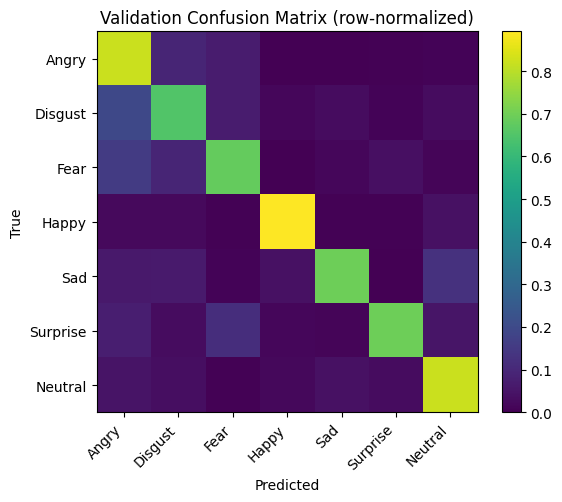

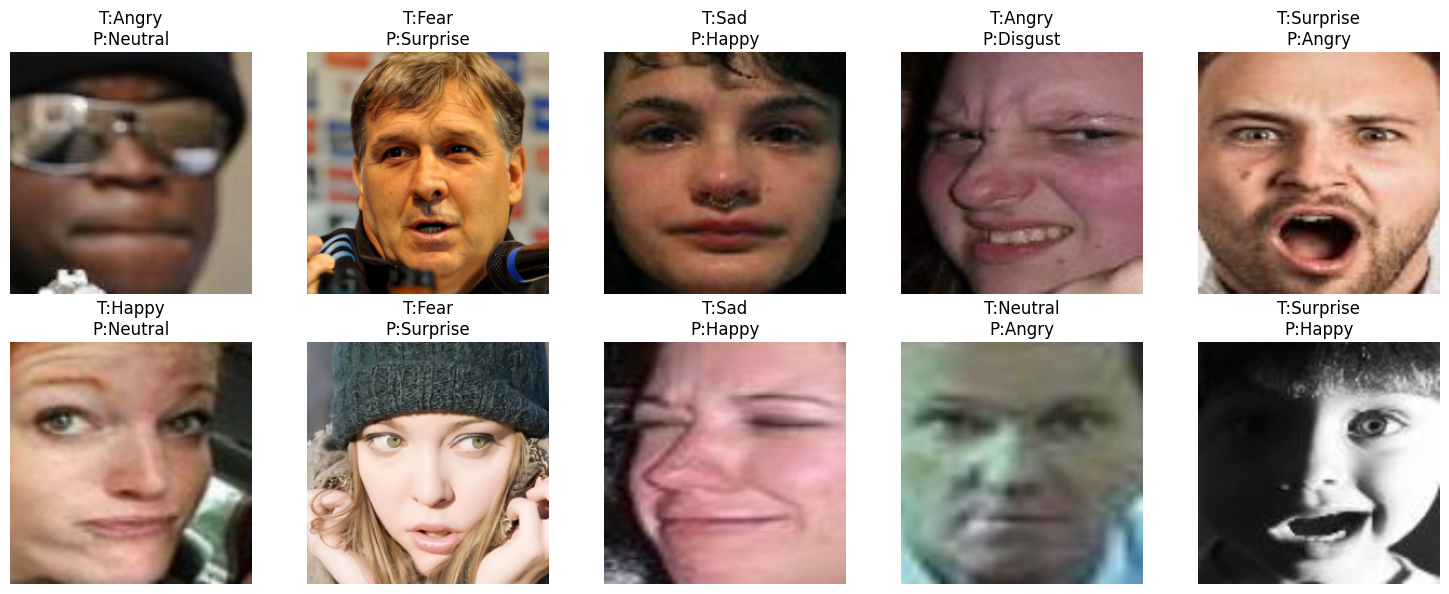

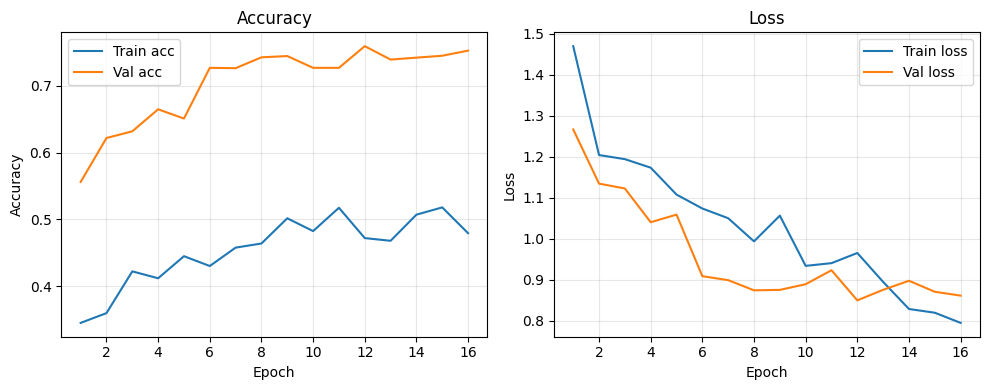

Gen gap (train_acc - val_acc): -0.2733
Signal: probable overfitting (large gap or rising val loss).


In [ ]:
# --- EVALUATION + DIAGNOSTICS ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- ensure test_loader exists to avoid NameError ---
if 'test_loader' not in globals():
    test_loader = None

# loader
_eval_loader = test_loader if ('test_loader' in globals() and test_loader is not None) else val_loader
_eval_name = "Test" if _eval_loader is test_loader else "Validation"

# load best checkpoint (handles compiled/ddp prefixes if any)
def sanitize_state_dict(sd):
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    if isinstance(sd, dict) and "model_state_dict" in sd:
        sd = sd["model_state_dict"]
    if any(k.startswith("module.") for k in sd.keys()):
        sd = {k.replace("module.", "", 1): v for k, v in sd.items()}
    if any(k.startswith("_orig_mod.") for k in sd.keys()):
        sd = {k.replace("_orig_mod.", "", 1): v for k, v in sd.items()}
    return sd

raw = torch.load("best_resnet18.pt", map_location=DEVICE)
state = sanitize_state_dict(raw) if isinstance(raw, dict) else raw
model.load_state_dict(state, strict=False)
model.eval()

# collect predictions
all_preds, all_labels = [], []
mis_dataset_idx = []
amp_enabled = (DEVICE.type == "cuda")
base_idx = 0

with torch.no_grad(), torch.amp.autocast('cuda', enabled=amp_enabled):
    for images, labels in _eval_loader:
        n = labels.size(0)
        images = images.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = model(images)
        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

        # record dataset indices of misclassified samples
        mism = (preds != labels).cpu().numpy().astype(bool)
        mis_idx_batch = np.nonzero(mism)[0]
        if mis_idx_batch.size > 0:
            mis_dataset_idx.extend((base_idx + mis_idx_batch).tolist())
        base_idx += n

all_preds = np.asarray(all_preds, dtype=np.int64)
all_labels = np.asarray(all_labels, dtype=np.int64)

# metrics
print(f"{_eval_name} Classification Report:")

labels_idx = list(range(NUM_CLASSES))
print(classification_report(
    all_labels, all_preds,
    labels=labels_idx,
    target_names=RAF_ORDER,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(all_labels, all_preds, labels=labels_idx)

overall_acc = (cm.diagonal().sum() / max(1, cm.sum()))
print(f"Overall accuracy: {overall_acc:.4f}")

acc_per_class = cm.diagonal() / np.clip(cm.sum(axis=1), a_min=1, a_max=None)
for cls, acc in zip(RAF_ORDER, acc_per_class):
    print(f"{cls:>10s}: {acc:.2%}")

# to warn if any classes absent in the evaluation set
present = set(all_labels.tolist())
absent_labels = [RAF_ORDER[i] for i in labels_idx if i not in present]
if absent_labels:
    print("Note: absent in this split ->", absent_labels)

# confusion matrix heatmap
cm_row = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), a_min=1, a_max=None)
plt.figure(figsize=(6,5))
plt.imshow(cm_row, interpolation='nearest')
plt.title(f"{_eval_name} Confusion Matrix (row-normalized)")
plt.colorbar()
ticks = np.arange(len(RAF_ORDER))
plt.xticks(ticks, RAF_ORDER, rotation=45, ha='right')
plt.yticks(ticks, RAF_ORDER)
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# visualize a few misclassified samples
if len(mis_dataset_idx) > 0:
    import random
    from torchvision.transforms.functional import to_pil_image

    base_ds = _eval_loader.dataset
    if hasattr(base_ds, "base"):  # unwrap our attach_transform wrapper
        base_ds = base_ds.base

    samp = random.sample(mis_dataset_idx, min(10, len(mis_dataset_idx)))

    cols = 5
    rows = int(np.ceil(len(samp)/cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i, didx in enumerate(samp, 1):
        img, _ = _eval_loader.dataset[didx]  # safe because val/test loader uses shuffle=False
        plt.subplot(rows, cols, i)
        # always denormalize for correct colors
        x = img.clone()
        if x.ndim == 3 and x.shape[0] == 3:
            x = x * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            x = x.clamp(0,1)
        plt.imshow(np.transpose(x.cpu().numpy(), (1, 2, 0)))

        true_lbl = RAF_ORDER[all_labels[didx]] if 0 <= all_labels[didx] < NUM_CLASSES else "?"
        pred_lbl = RAF_ORDER[all_preds[didx]]  if 0 <= all_preds[didx]  < NUM_CLASSES else "?"
        plt.title(f"T:{true_lbl}\nP:{pred_lbl}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found to visualize.")


# --- Learning curves: detect over/underfitting ---
import numpy as np
import matplotlib.pyplot as plt

def _plot_learning_curves(tr_acc_hist, tr_loss_hist, va_acc_hist, va_loss_hist):
    epochs = np.arange(1, len(tr_acc_hist)+1)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].plot(epochs, tr_acc_hist, label="Train acc")
    ax[0].plot(epochs, va_acc_hist, label="Val acc")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy"); ax[0].set_title("Accuracy")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs, tr_loss_hist, label="Train loss")
    ax[1].plot(epochs, va_loss_hist, label="Val loss")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss"); ax[1].set_title("Loss")
    ax[1].legend(); ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # diagnostics
    gap_acc = float(tr_acc_hist[-1]) - float(va_acc_hist[-1])
    loss_up = (len(va_loss_hist) >= 3) and (va_loss_hist[-1] > min(va_loss_hist[:-1]))
    print(f"Gen gap (train_acc - val_acc): {gap_acc:+.4f}")
    if gap_acc >= 0.10 or loss_up:
        print("Signal: probable overfitting (large gap or rising val loss).")
    elif tr_acc_hist[-1] < 0.7 and va_acc_hist[-1] < 0.7:
        print("Signal: probable underfitting (both accuracies low).")
    else:
        print("Signal: fit looks reasonable.")

if all(name in globals() for name in ["tr_acc_hist","tr_loss_hist","va_acc_hist","va_loss_hist"]):
    try:
        _plot_learning_curves(tr_acc_hist, tr_loss_hist, va_acc_hist, va_loss_hist)
    except Exception as e:
        print("Learning-curve plot failed:", e)
else:
    print("Learning curves unavailable. To enable, record metrics during training:")
    print("  tr_acc_hist.append(tr_acc); tr_loss_hist.append(tr_loss); va_acc_hist.append(va_acc); va_loss_hist.append(va_loss)")



# Export trained model
This saves the model as a .pt file for deployment.

In [ ]:
# --- Export: plain backbone, old label order + sanity check ---
import os
import torch
import torch.nn as nn
from torchvision import models

def sanitize_state_dict(sd):
    # unwrap common containers
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    if isinstance(sd, dict) and "model_state_dict" in sd:
        sd = sd["model_state_dict"]
    # strip DDP prefix
    if any(k.startswith("module.") for k in sd.keys()):
        sd = {k.replace("module.", "", 1): v for k, v in sd.items()}
    # strip torch.compile prefix
    if any(k.startswith("_orig_mod.") for k in sd.keys()):
        sd = {k.replace("_orig_mod.", "", 1): v for k, v in sd.items()}
    return sd

# Rebuild backbone and head
export_model = models.resnet18(weights=None)
export_model.fc = nn.Linear(export_model.fc.in_features, NUM_CLASSES)

# Load weights (prefer best checkpoint)
if os.path.isfile("best_resnet18.pt"):
    raw = torch.load("best_resnet18.pt", map_location="cpu")
    state = sanitize_state_dict(raw)
else:
    # fallback to in-memory model (handles compiled models too)
    to_save = getattr(model, "_orig_mod", model)
    state = to_save.state_dict()

missing, unexpected = export_model.load_state_dict(state, strict=False)
if missing or unexpected:
    print("load_state_dict info -> missing:", missing, " unexpected:", unexpected)

export_model.eval()
torch.save(export_model, "raf_affectnet_balanced_ResNet18.pt")

with open("labels.txt","w") as f:
    for s in RAF_ORDER:
        f.write(s + "\n")

print("Wrote raf_affectnet_balanced_ResNet18.pt and labels.txt")

# --- Sanity check: shape only (PyTorch 2.6 safe load) ---
import torch
from torchvision.models.resnet import ResNet
torch.serialization.add_safe_globals([ResNet])  # allowlist class used in the saved model

m = torch.load(
    "raf_affectnet_balanced_ResNet18.pt",
    map_location="cpu",
    weights_only=False  # required for full model objects
).eval()

x = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    y = m(x)
assert y.shape == (1, NUM_CLASSES), f"Unexpected output shape: {y.shape}"
print("OK:", y.shape)

Wrote raf_affectnet_balanced_ResNet18.pt and labels.txt
OK: torch.Size([1, 7])


In [ ]:
# Download .pt:

from google.colab import files
files.download("raf_affectnet_balanced_ResNet18.pt")
files.download("labels.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>